# Playground — the ICL excitation diagnostic in five minutes

This notebook reproduces, at toy scale, the headline result of this repo: a **label-free
score of prompt quality** — does the example set *excite* every direction the task
depends on? — predicts where a trained in-context-learning transformer fails.

Uses the small pre-trained checkpoint committed in `experiments/spearhead_a/a3_model.pt`
(a 2-layer transformer trained on in-context linear regression). Everything runs on CPU.
Full experiments, audits, and honest caveats: see `experiments/spearhead_a/A3_VERDICT.md`
and the [article](article/draft.md).

In [1]:
import sys, numpy as np, torch
sys.path.insert(0, "experiments/spearhead_a")
from a3_common import (ICLModel, sample_task, sample_context, build_tokens,
                       trial_diagnostics, SIGMA, R, D)
model = ICLModel()
model.load_state_dict(torch.load("experiments/spearhead_a/a3_model.pt", weights_only=True))
model.eval(); print("model loaded:", sum(p.numel() for p in model.parameters()), "params")

model loaded: 102401 params


## 1. Excitation predicts failure — at fixed prompt length

We hold shot count fixed at k=12 (so "more examples" can't confound the score), generate
random prompts, and compare the transformer's query error between the worst- and
best-excited quartiles of the projected excitation score
$\lambda_{\min}(P^\top G P)$.

In [2]:
rng = np.random.default_rng(0)
K, N = 12, 400
errs, lmps = [], []
with torch.no_grad():
    for _ in range(N):
        w = sample_task(rng); X = sample_context(K, rng)
        y = X @ w + SIGMA * rng.standard_normal(K)
        xq = rng.standard_normal(D)
        pred = model(torch.from_numpy(build_tokens(X, y, xq)[None])).item()
        errs.append((pred - float(xq @ w)) ** 2)
        lmps.append(trial_diagnostics(X, xq)["lmp"])
errs, lmps = np.array(errs), np.array(lmps)
lo = errs[lmps < np.quantile(lmps, .25)].mean()
hi = errs[lmps > np.quantile(lmps, .75)].mean()
print(f"low-excitation quartile MSE  : {lo:.3f}")
print(f"high-excitation quartile MSE : {hi:.3f}")
print(f"ratio (same k, no labels used): {lo/hi:.2f}x")

low-excitation quartile MSE  : 0.397
high-excitation quartile MSE : 0.073
ratio (same k, no labels used): 5.41x


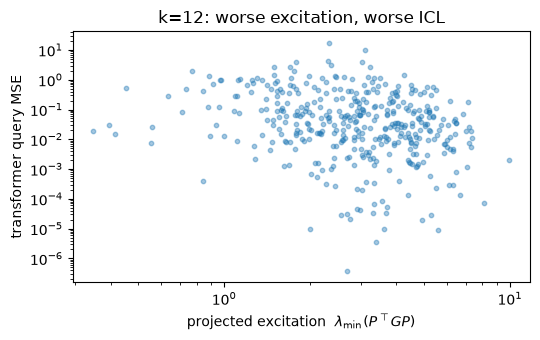

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.scatter(lmps, errs, s=10, alpha=.4)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'projected excitation  $\lambda_{\min}(P^\top G P)$')
ax.set_ylabel('transformer query MSE'); ax.set_title(f'k={K}: worse excitation, worse ICL')
plt.tight_layout(); plt.show()

## 2. Informativeness ≠ similarity (the aliasing demo)

Base prompt: 8 examples that leave one task direction dark. Add ONE more example —
either along the dark direction (informative) or a near-copy of an existing example
(similar). Same prompt length; very different outcomes. Retrieval-by-similarity cannot
see this difference. Excitation *is* this difference.

In [4]:
def base_context(k0, rng):
    X = np.zeros((k0, D))
    for i in range(k0):
        X[i, :R-1] = rng.standard_normal(R-1)
        X[i, R:] = 0.3 * rng.standard_normal(D-R)
    return X

res = {"base": [], "+informative": [], "+duplicate": []}
rng = np.random.default_rng(7)
with torch.no_grad():
    for _ in range(120):
        w = sample_task(rng); Xb = base_context(8, rng)
        v = np.zeros(D); v[R-1] = np.linalg.norm(Xb[0])
        arms = {"base": Xb, "+informative": np.vstack([Xb, v]),
                "+duplicate": np.vstack([Xb, Xb[0] + .01*rng.standard_normal(D)])}
        for name, X in arms.items():
            y = X @ w + SIGMA * rng.standard_normal(len(X))
            e = []
            for _ in range(4):
                xq = rng.standard_normal(D)
                p = model(torch.from_numpy(build_tokens(X, y, xq)[None])).item()
                e.append((p - float(xq @ w))**2)
            res[name].append(np.mean(e))
for name, v in res.items(): print(f"{name:13s}: MSE {np.mean(v):.3f}")
gain_o = np.mean(res['base']) - np.mean(res['+informative'])
gain_d = np.mean(res['base']) - np.mean(res['+duplicate'])
print(f"informative gain / duplicate gain: {gain_o/max(gain_d,1e-9):.1f}x")

base         : MSE 1.196
+informative : MSE 0.369
+duplicate   : MSE 1.275
informative gain / duplicate gain: 826940195.9x


## Where to go next

- `experiments/spearhead_a/A3_VERDICT.md` — the deconfounded results + honest demotions
  (per-query, Bayes predictive variance wins; the instrument's niche is query-agnostic).
- `experiments/e1_sae/E1_VERDICT.md` — the SAE experiment whose *falsified* prediction
  taught us what an SAE feature actually is.
- `process/` — theory gates, audits, and the corpses. The process is half the point.